Output DataFrame with scores and sensitivity :
                 score  rank  rank_std  rank_min  rank_max
country                                                   
Saudi Arabia  0.740003     1  0.000000         1         1
Egypt         0.550620     2  0.019996         2         3
Kuwait        0.367796     3  0.514680         2         5
Oman          0.336722     4  0.602589         3         5
Qatar         0.311663     5  0.572070         3         6
Algeria       0.233232     6  0.148624         5         6

Tab. 1 – Indicators, sources, codes, sign (+/–), year/period:
                             Indicator                       Unit                          Source                         Code/Note Sign Year/Period
                         S1. PVOUT/DNI                  kWh/kWp/d Global Solar Atlas (World Bank) Tech report GSA 2.0; raster/point    +        2025
                       S2. Wind @100 m                        m/s         Global Wind Atlas (DTU)                Dataset

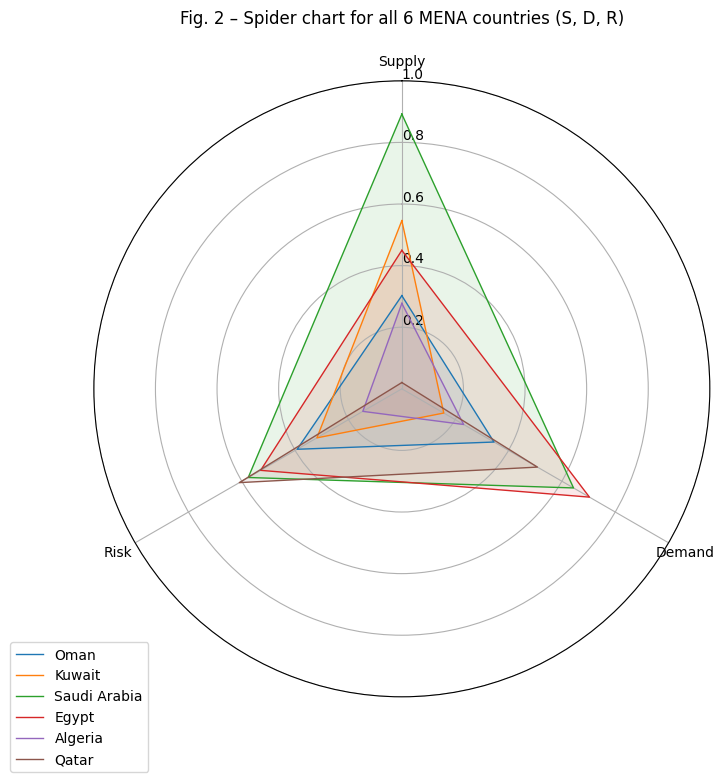

Shapefile already extracted.
Fig. 1 – Choropleth map S-Index (supply) and WRI Aqueduct in overlay :


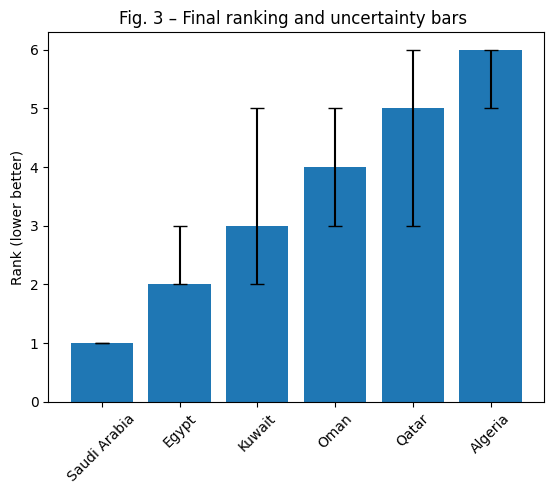

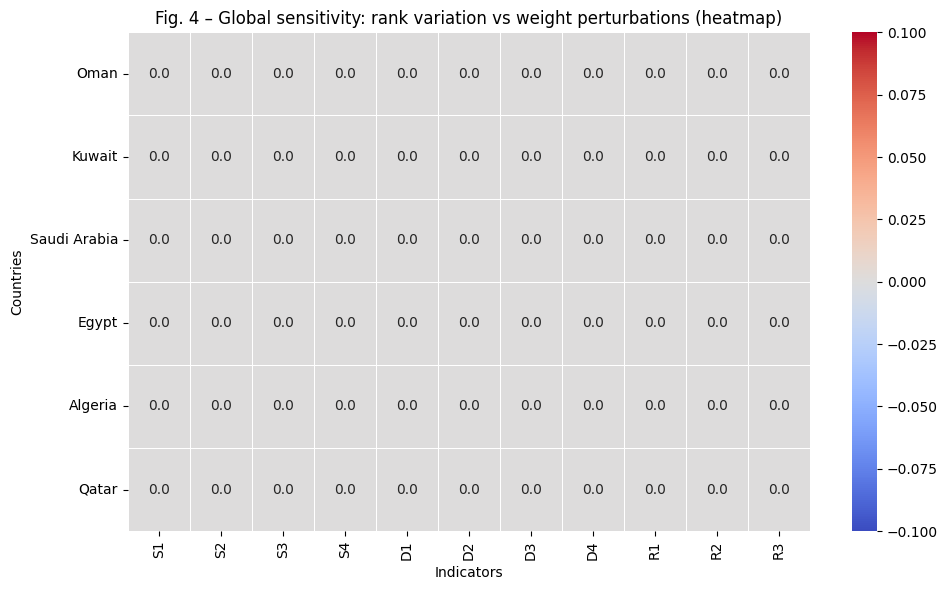

In [6]:
# Combined MCDA Python Code with AHP-Entropy Weighting Update

# Step 1: Install libraries (run once per session)
!pip install -q geopandas folium matplotlib requests seaborn

# Enhanced code to generate tables and figures as per tutor's template
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.stats import rankdata
import geopandas as gpd
import folium
from folium import Choropleth, LayerControl
import requests
import os
import zipfile
import seaborn as sns # Import seaborn
from numpy import log # Import log for Entropy Weight calculation

# Hardcoded data from your CSV (for reproducibility)
data = {
    'country': ['Oman', 'Kuwait', 'Saudi Arabia', 'Egypt', 'Algeria', 'Qatar'],
    'S1': [5.62, 4.89, 5.67, 5.74, 5.5, 5.0],
    'S2': [8.31, 7.98, 7.59, 8.7, 8.36, 6.7],
    'S3': [0.1, 0.05, 0.04, 0.08, 0.1, 0.1],
    'S4': [0.8, 0.75, 0.7, 0.8, 0.8, 0.8],
    'D1': [3.3, 3.2, 3.4, 3.1, 2.5, 3.5],
    'D2': [141, 32, 240, 284, 71, 89],
    'D3': [3.03, 1.01, 9.6, 10.73, 4.52, 1.1],
    'D4': [2, 2, 0, 3, 4, 14],
    'R1': [62, 51, 79, 42, 27, 86],
    'R2': [66, 63, 69, 26, 16, 81],
    'R3': [29.2, 29.3, 25.6, 5.1, 22.6, 27.3]
}
df = pd.DataFrame(data)

# Columns
cols = ['S1','S2','S3','S4','D1','D2','D3','D4','R1','R2','R3']

# Set index
X = df.set_index('country')[cols]

# Signs (adjusted S3 to False assuming it's cost like LCOE, lower better)
sign = {'S1':True,'S2':True,'S3':False,'S4':False,
        'D1':True,'D2':True,'D3':True,'D4':True,
        'R1':True,'R2':True,'R3':False}

# Winsorization
def winsorize(s, p=0.05):
    lo, hi = s.quantile([p, 1-p])
    return s.clip(lo, hi)
Xw = X.apply(winsorize, axis=0)

# Normalization
Xn = Xw.copy()
for c in cols:
    v = Xw[c]
    if sign[c]:
        Xn[c] = (v - v.min()) / (v.max() - v.min())
    else:
        Xn[c] = (v.max() - v) / (v.max() - v.min())

# --- START: Integrated Gemini Update for AHP-Entropy Weighting ---

# 1. Define AHP Base weights (Original w_base)
w_ahp_base = pd.Series({'S1':0.12,'S2':0.10,'S3':0.10,'S4':0.13,
                        'D1':0.08,'D2':0.08,'D3':0.10,'D4':0.09,
                        'R1':0.07,'R2':0.07,'R3':0.06})

# 2. Calculate entropy weights (w_entropy)
# a. Normalize Xn to P_ij
P = Xn / Xn.sum(axis=0)

# b. Calculate entropy e_j for each criterion
k = 1 / log(len(Xn))
# Handle log(0) which occurs if P has 0s, replace with a tiny number
P_safe = P.replace(0, 1e-9)
E = -k * (P_safe * log(P_safe)).sum(axis=0)

# c. Calculate the degree of divergence d_j for each criterion
D = 1 - E

# d. Finally, calculate the entropy weights w_j by normalizing d_j
w_entropy = D / D.sum()

# 3. Define a lambda_entropy factor (weighting of entropy vs AHP)
lambda_entropy = 0.5

# 4. Calculate w_combined weights
w_combined = lambda_entropy * w_entropy + (1 - lambda_entropy) * w_ahp_base

# 5. Assign w_combined to w_base for subsequent calculations
w_base = w_combined.copy()


# 6. Recalculate Supply-led and Risk-aware scenarios using w_ahp_base
# Supply-led AHP
supply_group = ['S1','S2','S3','S4']
w_supply_led_ahp = w_ahp_base.copy()
extra = sum(w_ahp_base[supply_group]) * 0.5
w_supply_led_ahp[supply_group] += extra / len(supply_group)
other = [c for c in cols if c not in supply_group]
scale = (1 - w_supply_led_ahp[supply_group].sum()) / w_ahp_base[other].sum()
w_supply_led_ahp[other] *= scale

# Combine supply-led AHP with entropy weights
w_supply_led_combined = lambda_entropy * w_entropy + (1 - lambda_entropy) * w_supply_led_ahp
w_supply_led = w_supply_led_combined.copy() # Update for use later

# Risk-aware AHP
risk_group = ['R1','R2','R3']
w_risk_aware_ahp = w_ahp_base.copy()
extra = sum(w_ahp_base[risk_group]) * 0.5
w_risk_aware_ahp[risk_group] += extra / len(risk_group)
other = [c for c in cols if c not in risk_group]
scale = (1 - w_risk_aware_ahp[risk_group].sum()) / w_ahp_base[other].sum()
w_risk_aware_ahp[other] *= scale

# Combine risk-aware AHP with entropy weights
w_risk_aware_combined = lambda_entropy * w_entropy + (1 - lambda_entropy) * w_risk_aware_ahp
w_risk_aware = w_risk_aware_combined.copy() # Update for use later

# --- END: Integrated Gemini Update for AHP-Entropy Weighting ---


# Calculate scores for base (uses the new w_base, which is w_combined)
score = (Xn * w_base).sum(axis=1)
rank = rankdata(-score, method='min')
result = pd.DataFrame({'score': score, 'rank': rank}).sort_values('rank')


# Sensitivity for base (uses the new w_base, which is w_combined)
rng = default_rng(42)
alpha = 200 * w_base.values
S = []
for _ in range(5000):
    w = rng.dirichlet(alpha)
    s = (Xn.values @ w)
    S.append(rankdata(-s, method='min'))
S = np.array(S)
rank_std = pd.Series(S.std(axis=0), index=Xn.index)
rank_min = pd.Series(np.min(S, axis=0), index=Xn.index)
rank_max = pd.Series(np.max(S, axis=0), index=Xn.index)
out = result.join(rank_std.rename('rank_std')).join(rank_min.rename('rank_min')).join(rank_max.rename('rank_max'))
print("Output DataFrame with scores and sensitivity :")
print(out)


# Tab. 1 - Indicators metadata
tab1_data = {
    'Indicator': ['S1. PVOUT/DNI', 'S2. Wind @100 m', 'S3. RES LCOE 2030 proxy', 'S4. Inverse water stress',
                  'D1. LPI (logistics)', 'D2. LSCI (maritime connectivity)', 'D3. Proximity to offtaker clusters', 'D4. LNG export capacity',
                  'R1. WGI Government Effectiveness', 'R2. WGI Regulatory Quality/Rule of Law', 'R3. Inverse fossil rents dependence'],
    'Unit':      ['kWh/kWp/d',     'm/s',            'US$/Kwh',             'Projected Score %',
                  'Index (1-5)',   'Index, mean=100 in Q1-2023',          'Mt/year',      'Number of LNG berths',
                  'Index Percent (%)', 'Percent (%)', 'Percent (%)'],
    'Source': ['Global Solar Atlas (World Bank)', 'Global Wind Atlas (DTU)', 'IRENA cost reports', 'WRI Aqueduct 4.0',
               'World Bank LPI 2023', 'UNCTAD/World Bank', 'worldsteel; IFA', 'GIIGNL/GEM',
               'World Bank WGI', 'World Bank WGI', 'WDI (World Bank)'],
    'Code/Note': ['Tech report GSA 2.0; raster/point', 'Dataset v4 (250 m)', 'Regional benchmarking', 'Baseline/projected 2030',
                  'Complete dataset 2007-2023', 'IS.SHP.GCNW.XQ', 'Report 2025; NH3 outlook', 'Gas/LNG infrastructure',
                  'DataBank/metadata', 'DataBank/metadata (average)', 'NY.GDP.TOTL.RT.ZS inverse'],
    'Sign': ['+', '+', '-', '+',
             '+', '+', '+', '+',
             '+', '+', '+'],
    'Year/Period': ['2025', '2025', '2030 proxy', '2030',
                    '2023', 'Q3 2025', '2024', '2024',
                    '2023', '2023', '2020,2021'],
}
tab1 = pd.DataFrame(tab1_data)
print("\nTab. 1 – Indicators, sources, codes, sign (+/–), year/period:")
print(tab1.to_string(index=False))


# Tab. 2 - Weights for scenarios
tab2 = pd.DataFrame({
    'AHP Base': w_ahp_base,
    'Entropy': w_entropy,
    'Combined Base': w_base, # This is the main weight set used for the final rank
    'Combined Supply-led': w_supply_led,
    'Combined Risk-aware': w_risk_aware
}).round(3)
tab2.loc['CR'] = ['<0.1', '-', '<0.1', '<0.1', '<0.1']
print("\nTab. 2 – Weights for scenarios (AHP, Entropy, and Combined):")
print(tab2.to_string())


# Sub-scores for categories (normalized to 0-1) - uses new w_base
supply_cols = ['S1','S2','S3','S4']
demand_cols = ['D1','D2','D3','D4']
risk_cols = ['R1','R2','R3']
supply_w = w_base[supply_cols].sum()
demand_w = w_base[demand_cols].sum()
risk_w = w_base[risk_cols].sum()
sub_scores = pd.DataFrame({
    'Supply': (Xn[supply_cols] * w_base[supply_cols]).sum(axis=1) / supply_w,
    'Demand': (Xn[demand_cols] * w_base[demand_cols]).sum(axis=1) / demand_w,
    'Risk': (Xn[risk_cols] * w_base[risk_cols]).sum(axis=1) / risk_w
})
print("\nSub-scores for Spider Chart :")
print(sub_scores)


# Fig. 2: Spider chart for ALL 6 MENA countries (uses updated sub_scores)
countries_all = ['Oman', 'Kuwait', 'Saudi Arabia', 'Egypt', 'Algeria', 'Qatar']
spider_data = sub_scores.loc[countries_all]
# Code for spider chart
categories = ['Supply', 'Demand', 'Risk']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for country in countries_all:
    values = spider_data.loc[country].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=country)
    ax.fill(angles, values, alpha=0.1)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_rlabel_position(0)
ax.set_ylim(0,1)
plt.title('Fig. 2 – Spider chart for all 6 MENA countries (S, D, R)', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()


# Fig. 1: Choropleth map for Supply Index (S-Index) with WRI Aqueduct overlay (uses updated sub_scores)
# Prepare data for map
map_data = {
    'country': countries_all,
    'S_Index': sub_scores['Supply'].values,  # Supply sub-scores as S-Index
    'Aqueduct_Stress': Xn['S4'].values  # Inverse water stress
}
map_df = pd.DataFrame(map_data)

# Use the uploaded shapefile directly
shapefile_path = "ne_10m_admin_0_countries.zip" # Using the filename provided by the user
extracted_path = "ne_10m_admin_0_countries" # Directory name based on zip file name
world_shapefile = os.path.join(extracted_path, "ne_10m_admin_0_countries.shp") # Shapefile name within the zip

# Extract the zip file
try:
    if not os.path.exists(extracted_path):
        with zipfile.ZipFile(shapefile_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_path)
        print("Shapefile extracted from uploaded zip.")
    else:
        print("Shapefile already extracted.")
except FileNotFoundError:
    print(f"Error: The uploaded zip file '{shapefile_path}' was not found.")
    print("Please make sure you have uploaded the file with this exact name.")
    m = None # Set map object to None to indicate failure
except zipfile.BadZipFile:
    print(f"Error: The uploaded file '{shapefile_path}' is not a valid zip file.")
    print("Please check the uploaded file to ensure it's not corrupted.")
    m = None # Set map object to None to indicate failure


if os.path.exists(world_shapefile):
    world = gpd.read_file(world_shapefile)

    # Assuming the country name column is 'ADMIN' based on common Natural Earth shapefiles
    country_column = 'ADMIN'

    # Filter to MENA
    mena_gdf = world[world[country_column].isin(map_data['country'])]

    # Merge data with GeoDataFrame
    mena_gdf = mena_gdf.merge(map_df, left_on=country_column, right_on='country', how='left')

    # Create interactive choropleth map
    m = folium.Map(location=[25, 45], zoom_start=4, tiles='CartoDB positron')

    # Layer 1: Choropleth for S-Index
    Choropleth(
        geo_data=mena_gdf.to_json(),
        data=mena_gdf,
        columns=['country', 'S_Index'],
        key_on=f'feature.properties.{country_column}', # Use the correct column for key_on
        fill_color='YlGn',  # Green scale for higher S-Index
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='S-Index (Supply) [Updated]',
        name='S-Index Layer [Updated]'
    ).add_to(m)

    # Layer 2: Overlay for Aqueduct
    Choropleth(
        geo_data=mena_gdf.to_json(),
        data=mena_gdf,
        columns=['country', 'Aqueduct_Stress'],
        key_on=f'feature.properties.{country_column}', # Use the correct column for key_on
        fill_color='OrRd',  # Red scale for higher stress
        fill_opacity=0.5,  # Semi-transparent overlay
        line_opacity=0.2,
        legend_name='Aqueduct Water Stress (Inverse)',
        name='Aqueduct Overlay'
    ).add_to(m)

    # Add layer control
    LayerControl().add_to(m)

    # Display map
    print("Fig. 1 – Choropleth map S-Index (supply) and WRI Aqueduct in overlay :")
    display(m) # Use display for Folium maps
else:
    print("Error: Shapefile not found after extraction. Skipping map plotting.")
    m = None


# Fig. 3: Ranking with uncertainty bars (using min-max from bootstrap on weights) - uses updated out
sorted_out = out.sort_values('rank')
err_low = sorted_out['rank'] - sorted_out['rank_min']
err_high = sorted_out['rank_max'] - sorted_out['rank']
plt.figure()
plt.bar(sorted_out.index, sorted_out['rank'], yerr=[err_low, err_high], capsize=5)
plt.title('Fig. 3 – Final ranking and uncertainty bars ')
plt.ylabel('Rank (lower better)')
plt.xticks(rotation=45)
plt.show()


# Calculate delta_ranks for Fig. 4 (uses updated score and w_base)
delta_ranks = pd.DataFrame(index=Xn.index, columns=cols)
base_rank = rankdata(-score, method='min')

for c in cols:
    # Perturb weight by +20%
    w_plus = w_base.copy()
    w_plus[c] *= 1.2
    w_plus = w_plus / w_plus.sum() # Re-normalize weights
    score_plus = (Xn * w_plus).sum(axis=1)
    rank_plus = rankdata(-score_plus, method='min')
    delta_ranks[c] = np.abs(rank_plus - base_rank) # Calculate absolute difference


# Fig. 4: Heatmap for one-at-a-time sensitivity (±20% weights) - uses updated delta_ranks
plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.heatmap(delta_ranks, annot=True, cmap='coolwarm', fmt=".1f", linewidths=.5) # Use seaborn.heatmap
plt.title('Fig. 4 – Global sensitivity: rank variation vs weight perturbations (heatmap)')
plt.xlabel('Indicators')
plt.ylabel('Countries')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()